In [1]:
from objects.DataLoader import DataLoader
from config import config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_loader = DataLoader(config)

df = data_loader.load_train()

df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [4]:
quantitative = []
qualitative = []

for column in df.columns:
    if df[column].dtype == 'str':
        qualitative.append(column)
    else:
        quantitative.append(column)

print(qualitative)
print(quantitative)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'Enclos

In [5]:
missings = df.isnull().sum()

missings[missings > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


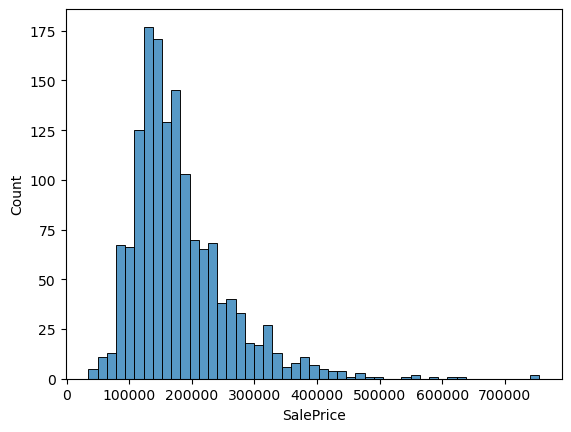

In [7]:
sns.histplot(df['SalePrice']);

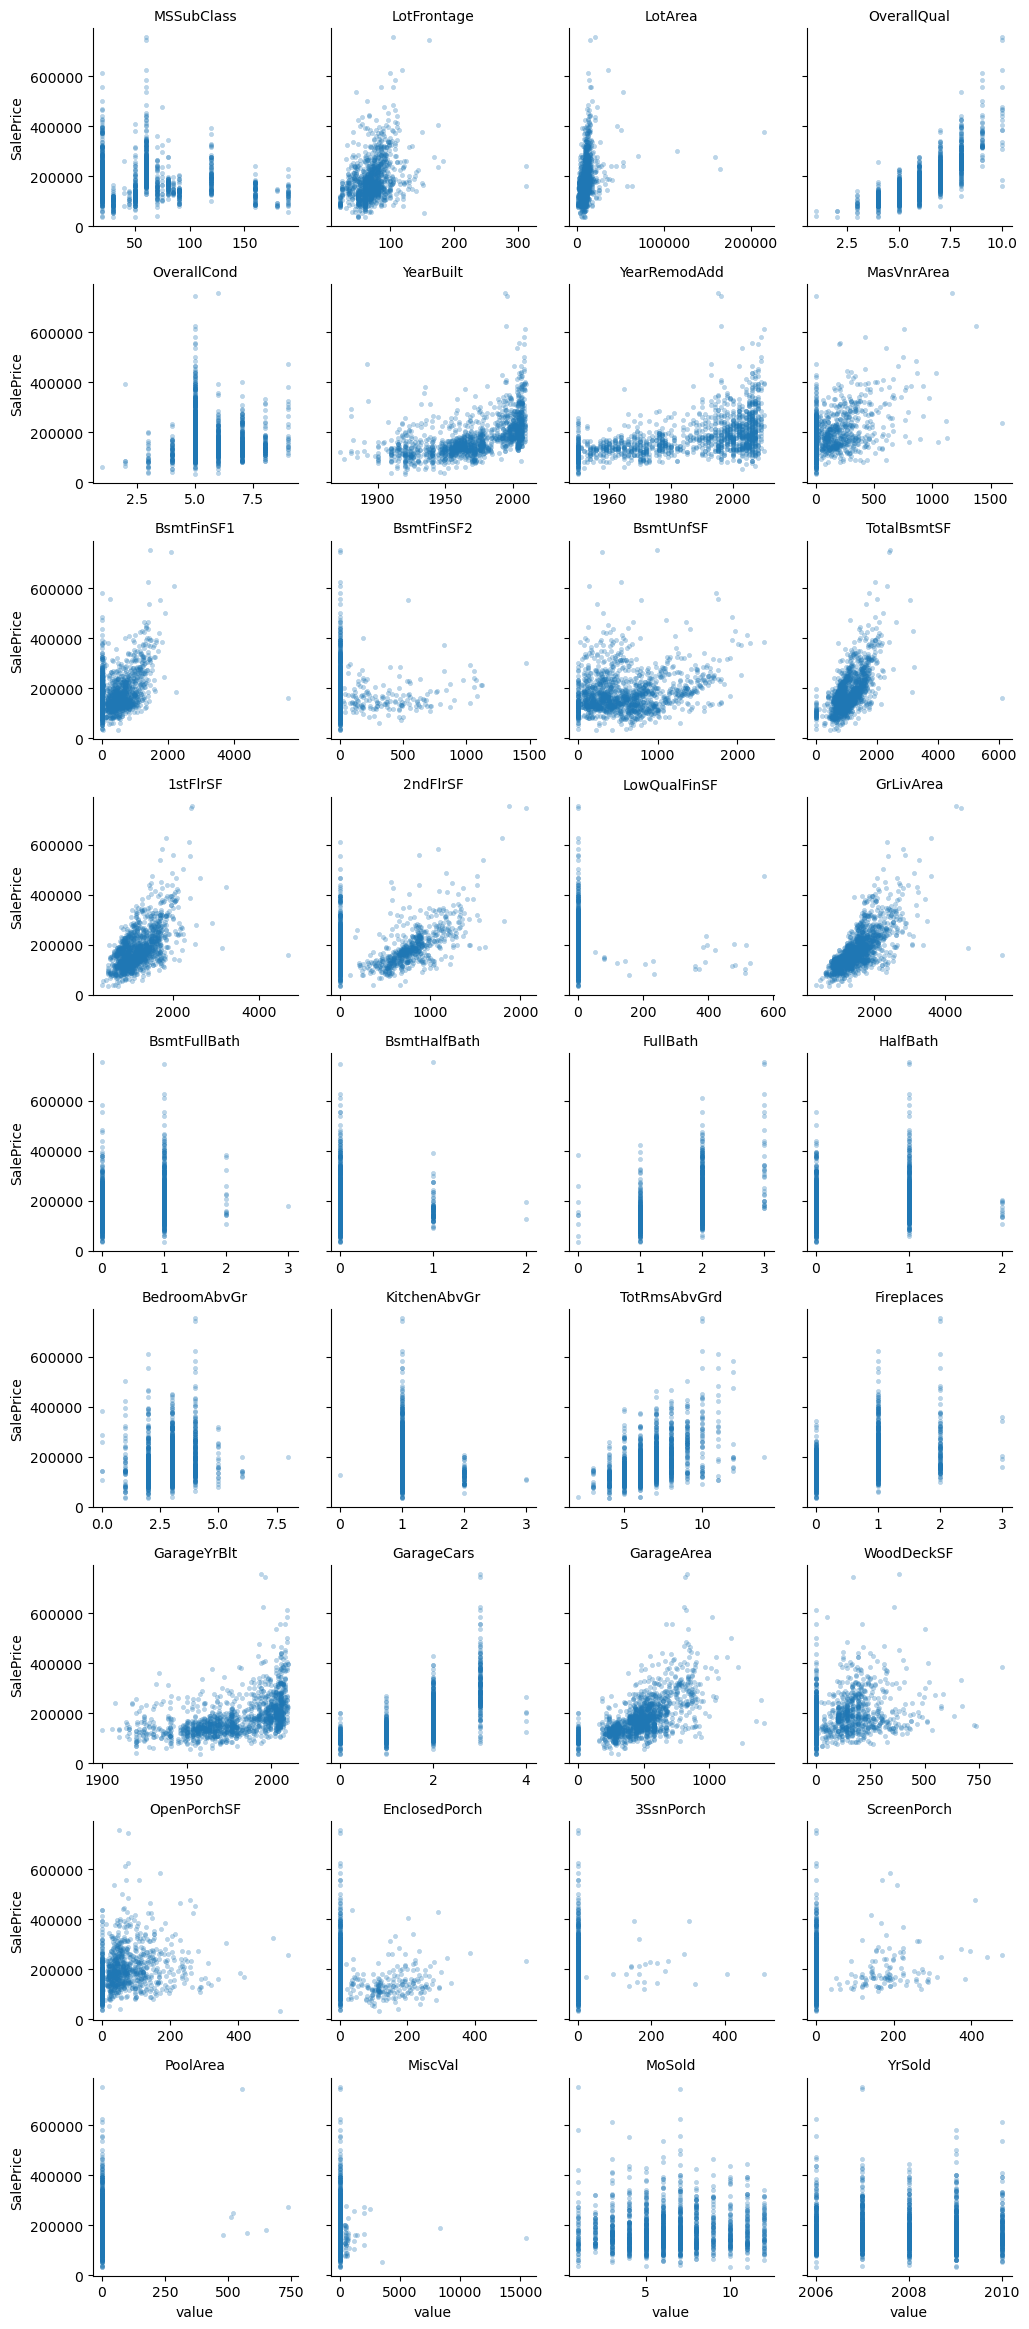

In [8]:
target = "SalePrice"
features = [c for c in quantitative if c != target]

long_df = df[features + [target]].melt(
    id_vars=target,
    value_vars=features,
    var_name="feature",
    value_name="value",
)

g = sns.FacetGrid(long_df, col="feature", col_wrap=4, sharex=False, sharey=True, height=2.6)
g.map_dataframe(sns.scatterplot, x="value", y=target, alpha=0.3, s=10, edgecolor=None)

g.set_titles("{col_name}")
g.tight_layout()
plt.show()

In [9]:
df[df['GrLivArea'] > 4000][['GrLivArea']]

,GrLivArea
Id,
524,4676
692,4316
1183,4476
1299,5642


In [10]:
df.loc[[524]]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


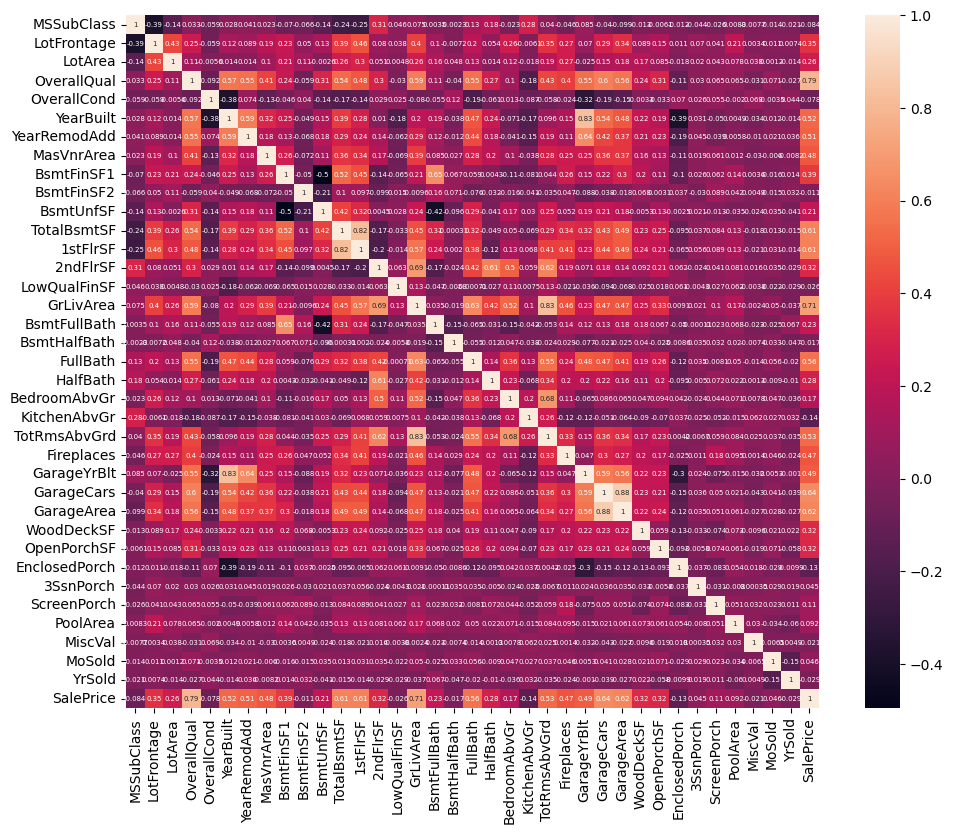

In [11]:
corrmat = df[quantitative].corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True, square=True, annot_kws={"size": 5});

In [12]:
test_df = data_loader.load_test()
missings = test_df.isnull().sum()

missings[missings > 0].sort_values(ascending=False)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageYrBlt       78
GarageQual        78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtFullBath       2
BsmtHalfBath       2
Functional         2
Utilities          2
GarageCars         1
GarageArea         1
TotalBsmtSF        1
KitchenQual        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
SaleType           1
dtype: int64

In [19]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   str    
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   str    
 5   Alley          107 non-null    str    
 6   LotShape       1459 non-null   str    
 7   LandContour    1459 non-null   str    
 8   Utilities      1457 non-null   str    
 9   LotConfig      1459 non-null   str    
 10  LandSlope      1459 non-null   str    
 11  Neighborhood   1459 non-null   str    
 12  Condition1     1459 non-null   str    
 13  Condition2     1459 non-null   str    
 14  BldgType       1459 non-null   str    
 15  HouseStyle     1459 non-null   str    
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt      1

In [14]:
df['SaleType'].value_counts()

SaleType
WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: count, dtype: int64

In [15]:
df['Electrical'].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [16]:
df['KitchenQual'].value_counts()

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

In [18]:
test_df['KitchenQual'].value_counts()

KitchenQual
TA    757
Gd    565
Ex    105
Fa     31
Name: count, dtype: int64

In [25]:
df['MoSold'].value_counts()

MoSold
6     253
7     234
5     204
4     141
8     122
3     106
10     89
11     79
9      63
12     59
1      58
2      52
Name: count, dtype: int64

In [31]:
def plot_target_vs_feature(
  df: pd.DataFrame,
  feature: str,
  target: str = 'SalePrice',
  *,
  log_target: bool = False,
  as_categorical: bool | None = None,
  figsize: tuple[float, float] = (10, 5),
):
  if feature not in df.columns:
    raise KeyError(f'Feature {feature!r} not in dataframe')
  if target not in df.columns:
    raise KeyError(f'Target {target!r} not in dataframe')

  x = df[feature]
  y = np.log1p(df[target]) if log_target else df[target]
  y_label = f'log1p({target})' if log_target else target

  is_categorical = (
    as_categorical
    if as_categorical is not None
    else not pd.api.types.is_numeric_dtype(x) or x.nunique(dropna=False) <= 15
  )

  fig, ax = plt.subplots(figsize=figsize)

  if is_categorical:
    plot_df = pd.DataFrame({
      'x': x.astype(str).fillna('__NA__'),
      'y': y,
    })
    order = (
      plot_df.groupby('x')['y']
      .median()
      .sort_values(ascending=False)
      .index
      .tolist()
    )
    data = [plot_df.loc[plot_df['x'] == cat, 'y'].values for cat in order]
    ax.boxplot(data, tick_labels=order, patch_artist=True)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel(feature)
    ax.set_ylabel(y_label)
    ax.set_title(f'{y_label} vs {feature}')
  else:
    mask = x.notna() & y.notna()
    ax.scatter(x[mask], y[mask], alpha=0.35, s=15, edgecolors='none')
    if mask.sum() > 1:
      coeffs = np.polyfit(x[mask], y[mask], deg=1)
      x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
      ax.plot(x_line, np.polyval(coeffs, x_line), color='C1', linewidth=2)
    ax.set_xlabel(feature)
    ax.set_ylabel(y_label)
    ax.set_title(f'{y_label} vs {feature}')

  fig.tight_layout()
  return fig, ax

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'SalePrice vs TotalPorchSF'}, xlabel='TotalPorchSF', ylabel='SalePrice'>)

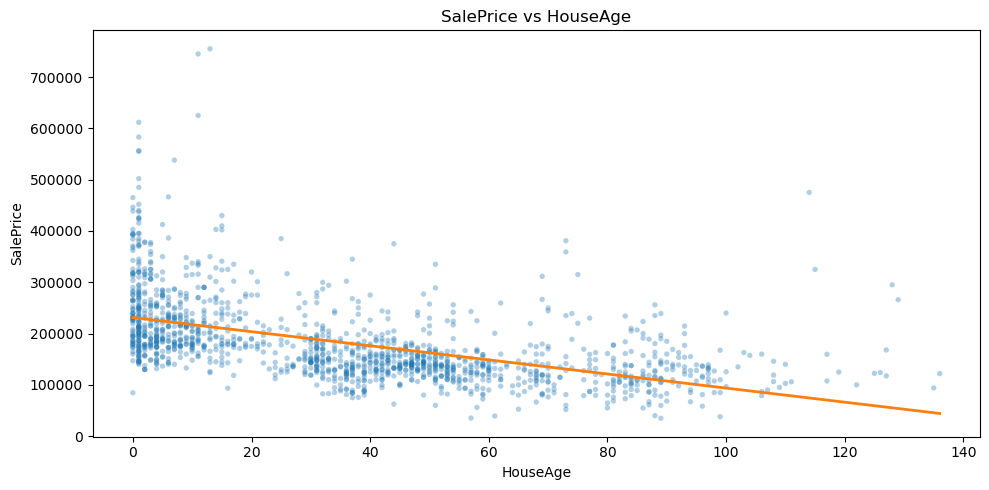

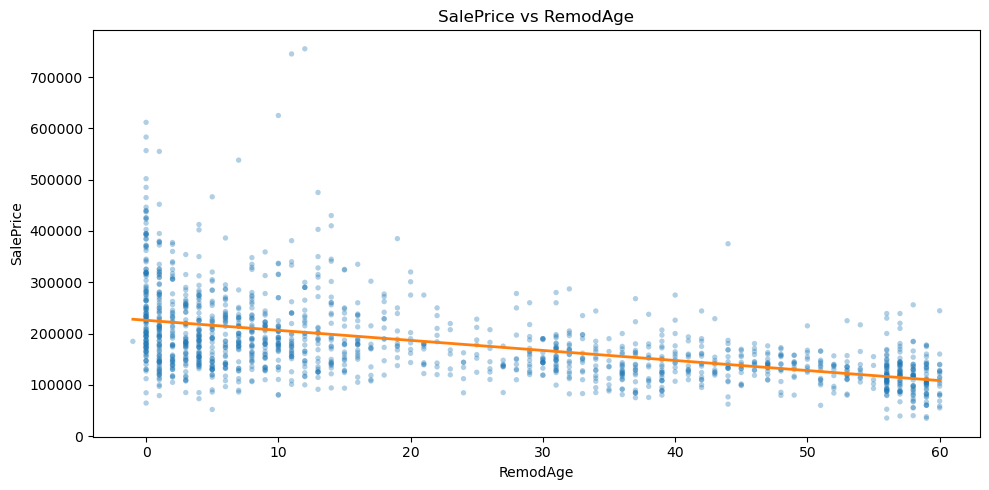

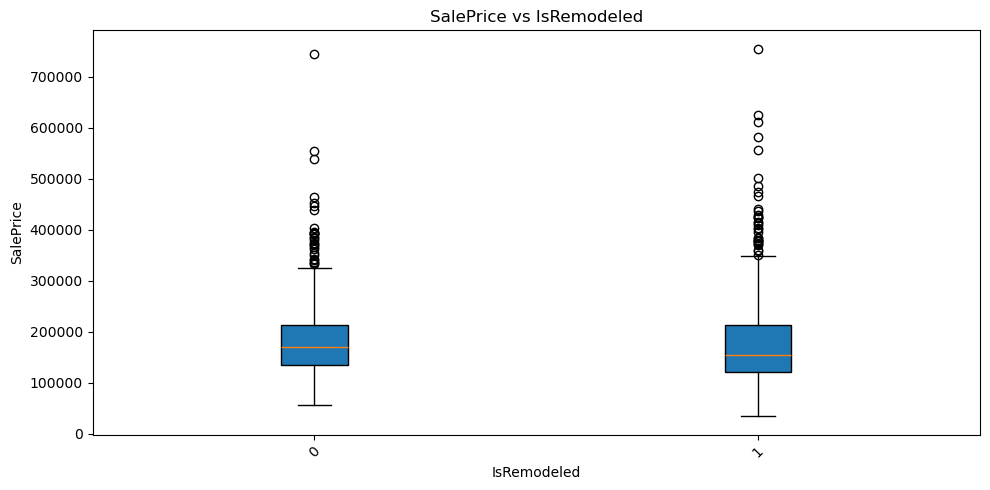

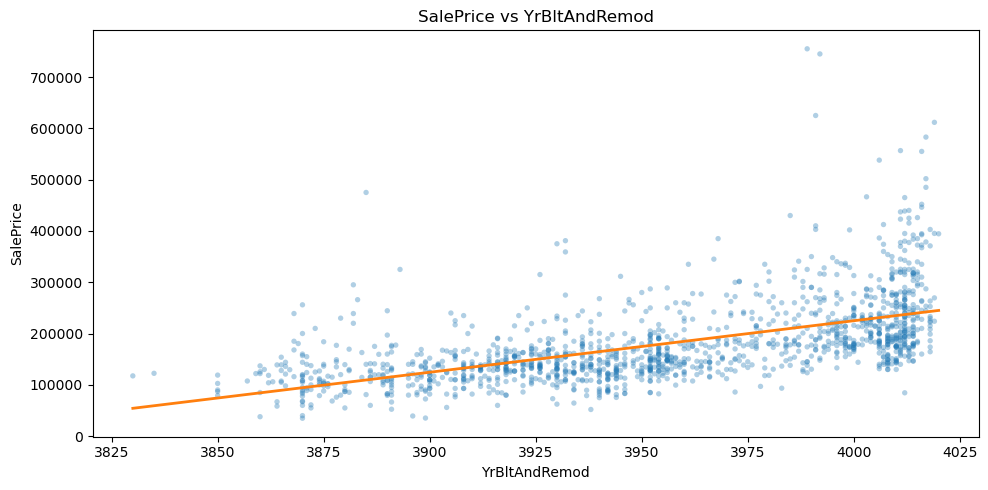

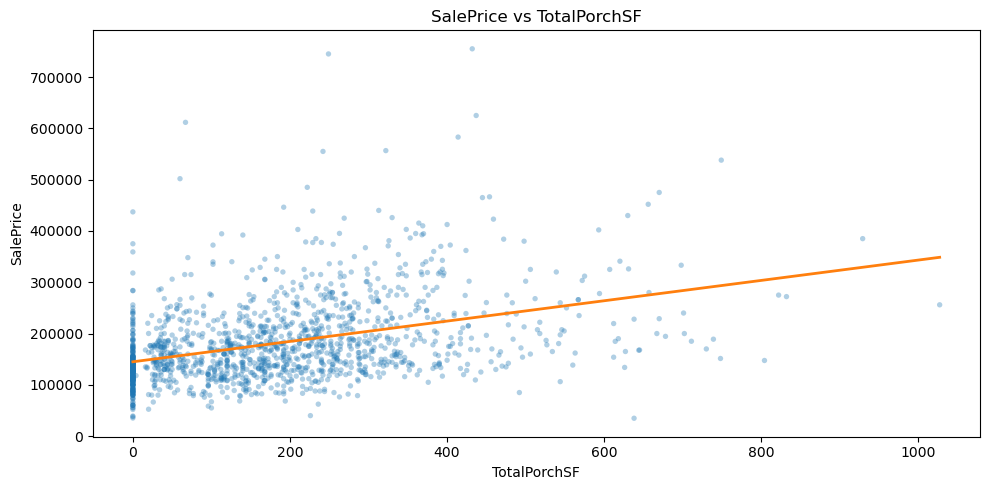

In [43]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['YrBltAndRemod'] = df['YearBuilt'] + df['YearRemodAdd']
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch']
      + df['ScreenPorch'] + df['WoodDeckSF'])
df['HasPorch'] = (df['TotalPorchSF'] > 0).astype(int)

plot_target_vs_feature(df, 'HouseAge')
plot_target_vs_feature(df, 'RemodAge')
plot_target_vs_feature(df, 'IsRemodeled')
plot_target_vs_feature(df, 'YrBltAndRemod')
plot_target_vs_feature(df, 'TotalPorchSF')

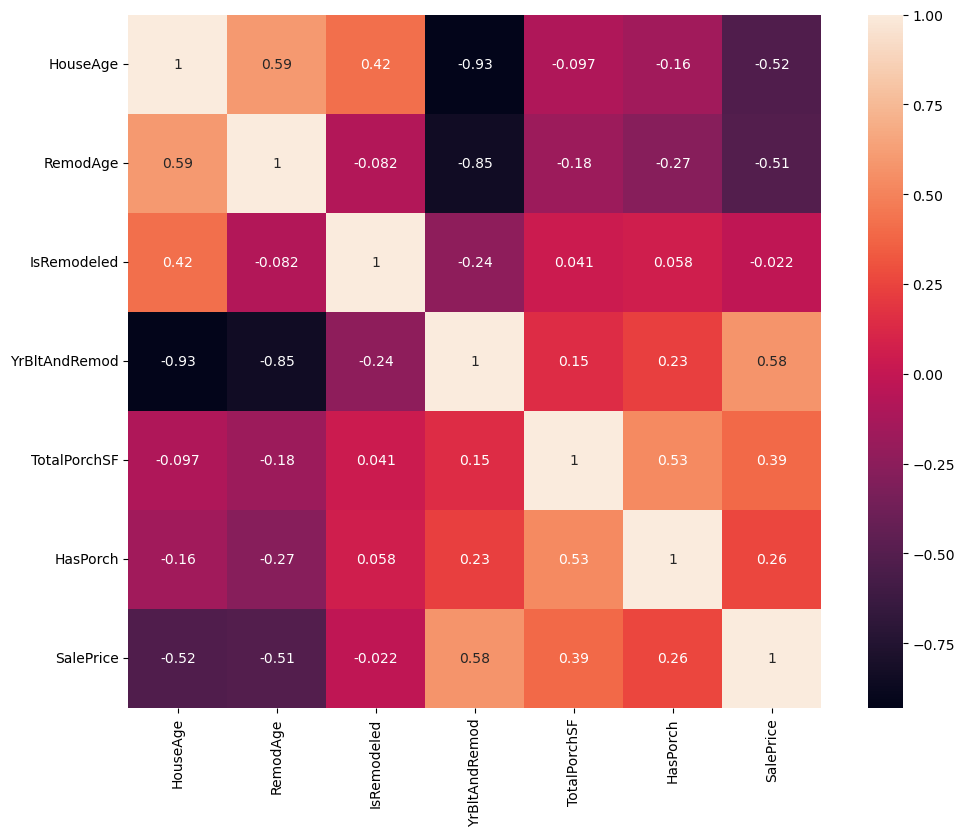

In [44]:
features = ['HouseAge', 'RemodAge', 'IsRemodeled', 'YrBltAndRemod','TotalPorchSF','HasPorch', 'SalePrice']
corrmat = df[features].corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True, square=True, annot_kws={"size": 10});


In [48]:
outliers = [30, 88, 462, 631, 1322]
df = df.drop(df.index[outliers])

In [54]:
overfit = []
for i in df.columns:
    counts = df[i].value_counts()
    zeros = counts.iloc[0]
    if zeros / len(df) * 100 > 99:
        overfit.append(i)

overfit

['Street', 'Utilities', 'Condition2', 'PoolArea']

In [55]:
df['Street'].value_counts()

Street
Pave    1434
Grvl       6
Name: count, dtype: int64

In [57]:
df['Utilities'].value_counts()

Utilities
AllPub    1439
NoSeWa       1
Name: count, dtype: int64

In [58]:
df['Condition2'].value_counts()

Condition2
Norm      1426
Feedr        5
Artery       2
RRNn         2
PosN         2
PosA         1
RRAn         1
RRAe         1
Name: count, dtype: int64

In [59]:
df['PoolArea'].value_counts()

PoolArea
0      1433
512       1
648       1
576       1
555       1
480       1
519       1
738       1
Name: count, dtype: int64

In [10]:
from dataclasses import dataclass

from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV
import numpy as np


@dataclass
class SearchResult:
    search: GridSearchCV
    best_score: float
    best_params_model: dict


def tune_sklearn_model(
    pipeline: BaseEstimator,
    X,
    y,
    param_grid: list[dict] | dict,
    cv,
    scoring: str | dict | None,
    *,
    model_step_name: str = "model",
    n_jobs: int = -1,
    refit: bool | str = True,
    verbose: int = 0,
    error_score: float | str = "raise",
) -> SearchResult:
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        refit=refit,
        verbose=verbose,
        error_score=error_score,
        return_train_score=False,
    )
    search.fit(X, y)

    best_params_full = dict(search.best_params_)
    prefix = f"{model_step_name}__"
    best_params_model = {
        k[len(prefix):]: v for k, v in best_params_full.items()
        if k.startswith(prefix)
    }

    return SearchResult(
        search=search,
        best_score=float(search.best_score_),
        best_params_model=best_params_model,
    )

In [2]:
from config import config
from objects.FeatureTransformer import FeatureTransformer
from objects.DataLoader import DataLoader
from objects.pipeline_builder import build_pipeline

data_loader = DataLoader(config)
ft = FeatureTransformer(config)

train = data_loader.load_train()
X, y = data_loader.split_data(train)

cv = KFold(**config.cv)

In [4]:
config.training_model = "ridge"
pipeline = build_pipeline(config)

param_grid = {
    "regressor__model__alpha": [0.01, 0.1, 1, 10, 50, 100, 500, 1000],
}

result = tune_sklearn_model(
    pipeline=pipeline,
    X=X,
    y=y,
    param_grid=param_grid,
    cv=cv,
    scoring=config.metric,
    model_step_name="regressor__model",
    n_jobs=-1,
    verbose=1,
)

print("best_score:", result.best_score)
print("best_params_model:", result.best_params_model)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6, 15, 16, 17, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15, 28, 32, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in 

best_score: -0.020336233725519626
best_params_model: {'alpha': 10}


In [5]:
import numpy as np

config.training_model = "lasso"
pipeline = build_pipeline(config)

param_grid = {
    "regressor__model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

result = tune_sklearn_model(
    pipeline=pipeline,
    X=X,
    y=y,
    param_grid=param_grid,
    cv=cv,
    scoring=config.metric,
    model_step_name="regressor__model",
    n_jobs=1,
    verbose=1,
)

print("best_score:", result.best_score)
print("best_params_model:", result.best_params_model)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.662e+00, tolerance: 1.940e-02
  model = cd_fast.enet_coordinate_descent(
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.024e+00, tolerance: 1.891e-02
  model 

best_score: -0.02071767965038575
best_params_model: {'alpha': 0.001}


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [16, 20, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6, 15, 16, 17, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [8]:
config.training_model = "elasticnet"
pipeline = build_pipeline(config)

param_grid = {
    "regressor__model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "regressor__model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    "regressor__model__max_iter": [100,200,300,400,500,800,1000,2000],
    "regressor__model__selection": ["cyclic", "random"],
}

result = tune_sklearn_model(
    pipeline=pipeline,
    X=X,
    y=y,
    param_grid=param_grid,
    cv=cv,
    scoring=config.metric,
    model_step_name="regressor__model",
    n_jobs=1,
    verbose=1,
)

print("best_score:", result.best_score)
print("best_params_model:", result.best_params_model)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.893e+00, tolerance: 1.940e-02
  model = cd_fast.enet_coordinate_descent(
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.501e+00, tolerance: 1.891e-02
  model 

best_score: -0.02047385220882312
best_params_model: {'alpha': 0.001, 'l1_ratio': 0.5, 'max_iter': 400, 'selection': 'random'}


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6, 15, 16, 17, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.062e+00, tolerance: 2.328e-02
  model = cd_fast.enet_coordinate_descent(


In [6]:
config.training_model = "KNN"
pipeline = build_pipeline(config)

param_grid = {
    "regressor__model__n_neighbors": [3, 5, 7, 11, 15, 21],
    "regressor__model__weights": ["uniform", "distance"],
    "regressor__model__p": [1, 2],
    "regressor__model__leaf_size": [20, 40],
}

result = tune_sklearn_model(
    pipeline=pipeline,
    X=X,
    y=y,
    param_grid=param_grid,
    cv=cv,
    scoring=config.metric,
    model_step_name="regressor__model",
    n_jobs=1,
    verbose=1,
)

print("best_score:", result.best_score)
print("best_params_model:", result.best_params_model)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15, 28, 32, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [16, 20, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns

best_score: -0.04557099335195135
best_params_model: {'leaf_size': 20, 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6, 15, 16, 17, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [9]:
config.training_model = "decision_tree"
pipeline = build_pipeline(config)

param_grid = {
    "regressor__model__max_depth": [None, 5, 10, 15, 20],
    "regressor__model__min_samples_leaf": [1, 2, 5, 10],
    "regressor__model__min_samples_split": [2, 5, 10, 20],
    "regressor__model__max_features": [None, "sqrt", "log2", 0.5],
}

result = tune_sklearn_model(
    pipeline=pipeline,
    X=X,
    y=y,
    param_grid=param_grid,
    cv=cv,
    scoring=config.metric,
    model_step_name="regressor__model",
    n_jobs=1,
    verbose=1,
)

print("best_score:", result.best_score)
print("best_params_model:", result.best_params_model)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15, 28, 32, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [16, 20, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns

best_score: -0.031076342081629738
best_params_model: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 10, 'min_samples_split': 10}


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6, 15, 16, 17, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [13]:
config.training_model = "random_forest"
pipeline = build_pipeline(config)

param_distributions = {
    "regressor__model__n_estimators": [100, 200, 300, 400, 500],
    "regressor__model__max_depth": [None, 10, 15, 20, 30],
    "regressor__model__min_samples_leaf": [0, 1, 3, 5, 7, 11],
    "regressor__model__min_samples_split": [1, 2, 3, 5, 8, 12, 15, 20],
    "regressor__model__max_features": ["sqrt", 0.5, None],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring=config.metric,
    n_jobs=1,
    random_state=config.general.seed,
    verbose=1,
)
search.fit(X, y)

prefix = "regressor__model__"
best_params_model = {
    k[len(prefix):]: v
    for k, v in search.best_params_.items()
    if k.startswith(prefix)
}

print("best_score:", search.best_score_)
print("best_params_model:", best_params_model)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15, 28, 32, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [16, 20, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns

best_score: -0.0185608645456709
best_params_model: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


In [15]:
config.training_model = "catboost"
config.need_scaler = False

config.models_params.catboost = {
    "verbose": False,
    "allow_writing_files": False,
    "random_state": config.general.seed,
}

pipeline = build_pipeline(config)

param_distributions = {
    "regressor__model__iterations": [500, 800, 1000, 1500],
    "regressor__model__depth": [4, 5, 6, 7, 8],
    "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.07],
    "regressor__model__l2_leaf_reg": [1, 3, 5, 10, 15],
    "regressor__model__random_strength": [1, 3, 5, 8],
    "regressor__model__subsample": [0.6, 0.7, 0.8, 0.9],
    "regressor__model__colsample_bylevel": [0.6, 0.8, 1.0],
    "regressor__model__min_data_in_leaf": [1, 5, 10, 20],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    cv=cv,
    scoring=config.metric,
    n_jobs=1,
    random_state=config.general.seed,
    verbose=1,
)
search.fit(X, y)

prefix = "regressor__model__"
best_params_model = {
    k[len(prefix):]: v
    for k, v in search.best_params_.items()
    if k.startswith(prefix)
}

print("best_score:", search.best_score_)
print("best_params_model:", best_params_model)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15, 28, 32, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [16, 20, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns

best_score: -0.01434966532202494
best_params_model: {'subsample': 0.7, 'random_strength': 3, 'min_data_in_leaf': 20, 'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 5, 'colsample_bylevel': 0.6}


In [16]:
config.training_model = "lightgbm"

config.models_params.lightgbm = {
    "verbose": -1,
    "force_col_wise": True,
    "n_jobs": 1,
    "random_state": config.general.seed,
}

pipeline = build_pipeline(config)

param_distributions = {
    "regressor__model__n_estimators": [400, 600, 800, 1000, 1200],
    "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.07],
    "regressor__model__num_leaves": [31, 63, 127, 255],
    "regressor__model__max_depth": [-1, 6, 8, 10, 12],
    "regressor__model__min_child_samples": [5, 10, 20, 30],
    "regressor__model__subsample": [0.6, 0.7, 0.8, 0.9],
    "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__model__reg_alpha": [0.0, 0.1, 1.0],
    "regressor__model__reg_lambda": [0.0, 1.0, 5.0, 10.0],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=cv,
    scoring=config.metric,
    n_jobs=1,
    random_state=config.general.seed,
    verbose=1,
)
search.fit(X, y)

prefix = "regressor__model__"
best_params_model = {
    k[len(prefix):]: v
    for k, v in search.best_params_.items()
    if k.startswith(prefix)
}

print("best_score:", search.best_score_)
print("best_params_model:", best_params_model)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15, 28, 32, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [16, 20, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns

best_score: -0.015330808273279697
best_params_model: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'num_leaves': 31, 'n_estimators': 1200, 'min_child_samples': 5, 'max_depth': 12, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


In [17]:
config.training_model = "xgboost"

config.models_params.xgboost = {
    "verbosity": 0,
    "n_jobs": 1,
    "random_state": config.general.seed,
}

pipeline = build_pipeline(config)

param_distributions = {
    "regressor__model__n_estimators": [400, 600, 800, 1000],
    "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.07],
    "regressor__model__max_depth": [4, 6, 8, 10],
    "regressor__model__min_child_weight": [1, 3, 5],
    "regressor__model__subsample": [0.6, 0.7, 0.8, 0.9],
    "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__model__reg_alpha": [0.0, 0.1, 1.0],
    "regressor__model__reg_lambda": [1.0, 5.0, 10.0],
    "regressor__model__gamma": [0.0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=cv,
    scoring=config.metric,
    n_jobs=1,
    random_state=config.general.seed,
    verbose=1,
)
search.fit(X, y)

prefix = "regressor__model__"
best_params_model = {
    k[len(prefix):]: v
    for k, v in search.best_params_.items()
    if k.startswith(prefix)
}

print("best_score:", search.best_score_)
print("best_params_model:", best_params_model)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 30] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [11, 15, 28, 32, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [16, 20, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns

best_score: -0.015173844061791897
best_params_model: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.6}
